In [2]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

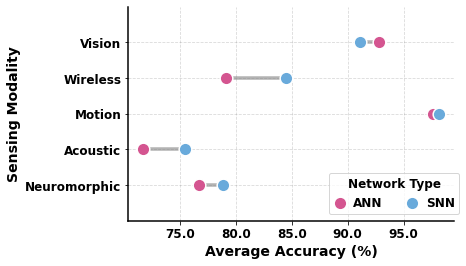

In [2]:
# Fig 2 (a) ANN vs SNN across sensing modalities (DumbBell plot)

sensings = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic'][::-1]
y = np.arange(len(sensings))

offset = 0.25
ann_mean_acc = np.array([92.53 + offset, 79.37 - offset, 97.92 - offset, 71.44 + offset, 76.39 + offset])[::-1]
snn_mean_acc = np.array([91.36 - offset, 84.19 + offset, 97.91 + offset, 75.64 - offset, 79.04 - offset])[::-1]

fig, ax = plt.subplots(figsize=(6.5, 3.8))

# difference lines
for i in range(len(y)):
    ax.plot([snn_mean_acc[i], ann_mean_acc[i]], [y[i], y[i]], color='0.7', linewidth=3.5, zorder=1)

# ANN points
ax.scatter(ann_mean_acc, y, s=160, edgecolors='white', linewidths=1.5, color='#D45590', label='ANN', zorder=3)

# SNN points
ax.scatter(snn_mean_acc, y, s=160, edgecolors='white', linewidths=1.5,color='#69AADB', label='SNN', zorder=3)

# 坐标轴设置（互换）
ax.set_yticks(y)
ax.set_yticklabels(sensings, fontsize=13)
ax.set_xlabel('Average Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)

leg = fig.legend(
    title='Network Type',
    loc='lower center',
    bbox_to_anchor=(0.85, 0.18), 
    ncol=2,
    handlelength=1.,
    handletextpad=0.6,
    prop={'weight': 'bold', 'size': 12},
)
leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(12)

# spine 样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.set_ylim(-1, 5)

fig.tight_layout()
plt.savefig('./fig2a.pdf', dpi=500, bbox_inches="tight")
plt.show()

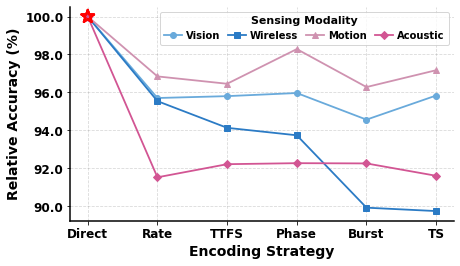

In [263]:
# Fig 2 (b) Heatmap of SNN performance across conventional sensing modalities and encoding methods

# ---------------------
# 1. data preparation
# ---------------------
modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic']
encodings = ['Direct', 'Rate', 'TTFS', 'Phase', 'Burst', 'TS']

data = np.array([
    [91.26, 87.34, 87.43, 87.58, 86.30, 87.46],  # Vision
    [83.86, 80.12, 78.94, 78.61, 75.41, 75.26],  # Wireless
    [97.90, 94.81, 94.43, 96.22, 94.26, 95.13],  # Motion
    [75.16, 68.79, 69.31, 69.35, 69.34, 68.85],  # Acoustic
])

direct = data[:, 0].reshape(-1, 1)
relative_acc = data / direct * 100  # Direct = 100%

# ----------------------
# 绘图
# ----------------------
fig, ax = plt.subplots(figsize=(6.5, 3.8))

colors = ["#69AADB", "#2b7bc5", "#CF92B0", "#D25593"]  
markers = ['o', 's', '^', 'D']

for i, modality in enumerate(modalities):
    ax.plot(encodings, relative_acc[i, :],
            marker=markers[i],
            color=colors[i],
            linewidth=1.8,
            markersize=6,
            label=modality)
    # 对 Direct 点加特殊标注
    ax.scatter(encodings[0], relative_acc[i, 0], 
               s=180, edgecolor='red', marker='*', facecolor='none', linewidth=2, zorder=5)

ax.set_ylabel('Relative Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Encoding Strategy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(encodings)))
ax.set_xticklabels(encodings)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)

legend = ax.legend(title='Sensing Modality', fontsize=11, ncol=4, loc='upper right', prop={'weight': 'bold'}, 
                   handlelength=1.8, handletextpad=0.4, columnspacing=.8, )
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(11)

fig.tight_layout()
plt.savefig('./fig2b.pdf', dpi=500, bbox_inches="tight")
plt.show()


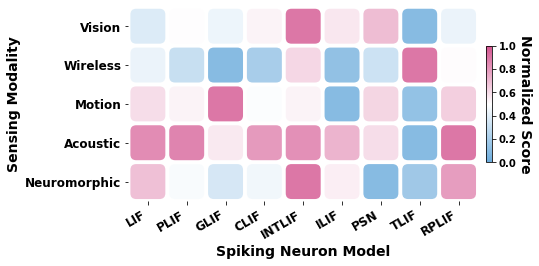

In [4]:
# Fig 2 (c) Neuron-wise performance landscape across sensing modalities

# Data
data = np.array([
    [91.36, 91.57, 91.46, 91.62, 92.27, 91.68, 91.90, 90.85, 91.44],  # Vision
    [84.19, 83.68, 82.74, 83.22, 84.96, 82.91, 83.75, 86.20, 84.51],  # Wireless
    [97.92, 97.89, 98.06, 97.87, 97.89, 97.69, 97.93, 97.71, 97.94],  # Motion
    [75.64, 75.77, 73.89, 75.38, 75.55, 74.87, 74.11, 70.93, 76.04],  # Acoustic
    [79.04, 78.29, 77.86, 78.19, 79.84, 78.54, 76.88, 77.19, 79.42],  # Neuromorphic
])

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
neurons = ['LIF', 'PLIF', 'GLIF', 'CLIF', 'INTLIF', 'ILIF', 'PSN', 'TLIF', 'RPLIF']

# convert to DataFrame
df_long = pd.DataFrame(data, index=modalities, columns=neurons).reset_index()
df_long = df_long.melt(id_vars='index', var_name='Neuron', value_name='Score')
df_long.rename(columns={'index': 'Modality'}, inplace=True)
# normalize scores per modality
# df_long['Score'] = df_long.groupby('Modality')['Score'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# ---------------------
# 2. plot settings
# ---------------------
fig, ax = plt.subplots(figsize=(7.5, 3.8))
cell_size = 0.8
radius = 0.15

# 每行独立 cmap
cmap = mcolors.LinearSegmentedColormap.from_list("row_cmap", ["#69AADB", "white", "#D45590"]) # 

for i, modality in enumerate(modalities):
    row_data = df_long[df_long['Modality'] == modality]
    # normalize per row
    row_min, row_max = row_data['Score'].min(), row_data['Score'].max()
    norm = mcolors.TwoSlopeNorm(vmin=row_min, vcenter=(row_min + row_max) / 2, vmax=row_max)
    
    for _, row in row_data.iterrows():
        x = neurons.index(row['Neuron'])
        y = i
        color = cmap(norm(row['Score']))
        
        rect = patches.FancyBboxPatch(
            (x - cell_size / 2, y - cell_size / 2),
            cell_size, cell_size,
            boxstyle=f"round,pad=0.05, rounding_size={radius}",
            linewidth=0,
            facecolor=color,
            alpha=0.8
        )
        ax.add_patch(rect)

# ---------------------
# 3. axis settings
# ---------------------
ax.set_xticks(range(len(neurons)))
ax.set_xticklabels(neurons, rotation=30, ha='right', va='top', fontweight='bold', fontsize=12)
ax.set_yticks(range(len(modalities)))
ax.set_yticklabels(modalities, fontweight='bold', fontsize=12)

ax.set_xlim(-0.5, len(neurons)-0.5)
ax.set_ylim(-0.5, len(modalities)-0.5)
ax.invert_yaxis()
ax.set_aspect('equal')  # 保证正方形格子

# 去掉网格和边框
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------
# 4. add global colorbar
# ---------------------
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=0, vmax=1)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.02)
cbar.set_label('Normalized Score', fontsize=14, fontweight='bold', rotation=-90, labelpad=16)
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xlabel('Spiking Neuron Model', fontweight='bold', fontsize=14)
ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)


fig.tight_layout()
plt.savefig('./fig2c.pdf', dpi=500, bbox_inches="tight")
plt.show()

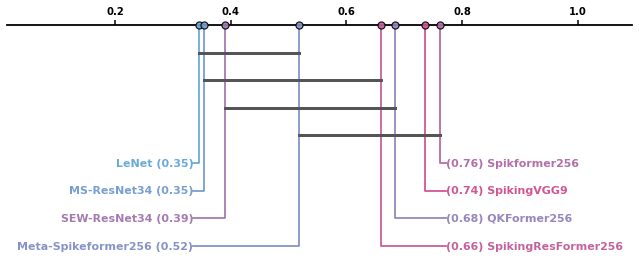

In [8]:
# Fig 2 (d) TODO need to finish topology-res.csv CD-diagram to give architecture selection advice across all sensing modalities

fig, ax = plt.subplots(figsize=(9.5, 3.8))
data = pd.read_csv('./topology-res.csv')
avg_rank = data.groupby(
    'dataset_name').accuracy.rank(pct=True).groupby(data.classifier_name).mean()
test_results = sp.posthoc_conover_friedman(
    data, melted=True, block_col='dataset_name', group_col='classifier_name', y_col='accuracy')

cd_cmap = mcolors.LinearSegmentedColormap.from_list(
    "row_cmap",
    ["#69AADB", "#789ED1", "#8792C7", "#9686BD", "#A57AB3", "#B46EA8", "#C3629E", "#D25593"]
)
classifiers = avg_rank.index.tolist()
n = len(classifiers)
colors = [cd_cmap(i/(n-1)) for i in range(n)]
palette = {clf: col for clf, col in zip(classifiers, colors)}

sp.critical_difference_diagram(avg_rank, test_results, 
                               label_props={'fontsize': 11, 'fontweight': 'bold'}, 
                               marker_props={
                                    "s": 50,                  # marker 大小
                                    "marker": "o",             # 符号
                                    "edgecolor": "k",          # 黑色边缘
                                    "linewidths": 1.2,         # 边缘线宽
                                    "alpha": 0.9
                                },
                                crossbar_props={
                                    "linewidth": 3.0,
                                    "linestyle": "-", 
                                    "color": "#555555"
                                },
                                elbow_props={
                                    "linewidth": 1.8,
                                },
                               color_palette=palette, ax=ax)
ax.spines['top'].set_linewidth(1.8)
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
ax.tick_params(axis='both', which='major', width=1.5, length=5, labelrotation=0)

# ax.margins(x=0.35)
ax.set_xlim(ax.get_xlim()[0] - 0.3,
            ax.get_xlim()[1] + 0.3)

fig.tight_layout()
plt.savefig('./fig2d.pdf', dpi=500, bbox_inches="tight")
plt.show()

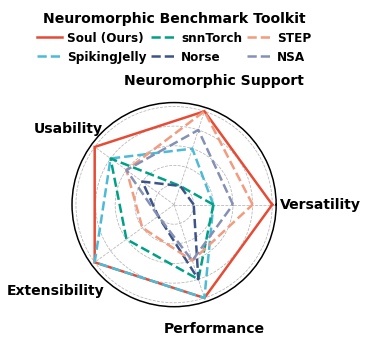

In [271]:
# fig5 (c) - radar chart of advantage comparison against other frontend benchmark toolkits

# -------------------------
# 1. Radar chart helper
# -------------------------
def radar_chart(ax, categories, values, linestyle, color, label):
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values = values + values[:1]

    ax.plot(
        angles, values,
        linestyle,
        color=color,
        linewidth=2.5,
        label=label
    )
    # ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', pad=18) 

    for label in ax.get_xticklabels():
        if label.get_text() in ['Versatility', 'Extensibility']:
            label.set_y(-0.15)

    ax.set_yticklabels([])

    ax.spines['polar'].set_linewidth(1.5)
    ax.grid(linestyle='--', alpha=0.9)


# -------------------------
# 2. Example data (5-dim)
# -------------------------

fig, ax = plt.subplots(
    1, 1,
    figsize=(5.5, 5.5),
    subplot_kw=dict(polar=True)
)

# application support, model support, documentation, add new model, ...
categories = ['Versatility', 'Neuromorphic Support', 'Usability', 'Extensibility', 'Performance']
method_soul = [5, 5, 5, 5, 5]
method_sj = [2, 3, 4, 5, 5]
method_snntorch = [2, 1, 4, 3, 4]
method_norse = [1, 1, 2, 1, 4]
method_step = [4, 5, 3, 2, 3]
method_nsa = [3, 4, 3, 1, 3]

radar_chart(ax, categories, method_soul, '-', '#E64B35', 'Soul (Ours)')
radar_chart(ax, categories, method_sj, '--', '#4DBBD5', 'SpikingJelly')
radar_chart(ax, categories, method_snntorch, '--', '#00A087', 'snnTorch')
radar_chart(ax, categories, method_norse, '--', '#3C5488', 'Norse')
radar_chart(ax, categories, method_step, '--', '#F39B7F', 'STEP')
radar_chart(ax, categories, method_nsa, '--', '#8491B4', 'NSA') # neuromorphic sequential arena


legend = ax.legend(
    title='Neuromorphic Benchmark Toolkit',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3,
    frameon=False,
    handlelength=2.1, 
    handletextpad=0.4, 
    columnspacing=.4, 
    prop={'weight': 'bold', 'size':12},
)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

fig.tight_layout()
plt.savefig('./fig5c.pdf', dpi=500, bbox_inches="tight")
plt.show()


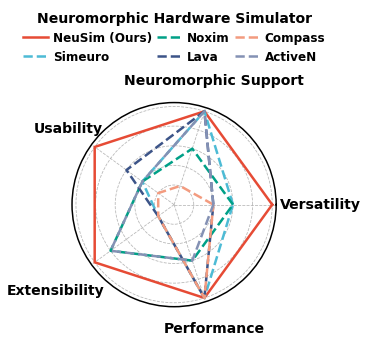

In [272]:
# fig5 (d) - radar chart of advantage comparison against other backend chip simulator toolkits

# -------------------------
# 1. Radar chart helper
# -------------------------
def radar_chart(ax, categories, values, linestyle, color, label):
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values = values + values[:1]

    ax.plot(
        angles, values,
        linestyle,
        color=color,
        linewidth=2.5,
        label=label
    )
    # ax.fill(angles, values, color=color, alpha=0.01)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', pad=18) 

    for label in ax.get_xticklabels():
        if label.get_text() in ['Versatility', 'Extensibility']:
            label.set_y(-0.15)

    ax.set_yticklabels([])

    ax.spines['polar'].set_linewidth(1.5)
    ax.grid(linestyle='--', alpha=0.9)


# -------------------------
# 2. Example data (5-dim)
# -------------------------

fig, ax = plt.subplots(
    1, 1,
    figsize=(5.5, 5.5),
    subplot_kw=dict(polar=True)
)

categories = ['Versatility', 'Neuromorphic Support', 'Usability', 'Extensibility', 'Performance']
method_neusim = [5, 5, 5, 5, 5]
method_simeuro = [3, 5, 2, 1, 5]
method_lava = [2, 5, 3, 1, 5]
method_noxim = [3, 3, 2, 4, 3]
method_compass = [2, 1, 1, 1, 5]
method_activen = [2, 5,2 ,4 ,3]

radar_chart(ax, categories, method_neusim, '-', '#E64B35', 'NeuSim (Ours)')
radar_chart(ax, categories, method_simeuro, '--', '#4DBBD5', 'Simeuro')
radar_chart(ax, categories, method_noxim, '--', '#00A087', 'Noxim')
radar_chart(ax, categories, method_lava, '--', '#3C5488', 'Lava')
radar_chart(ax, categories, method_compass, '--', '#F39B7F', 'Compass')
radar_chart(ax, categories, method_activen, '--', '#8491B4', 'ActiveN')

legend = ax.legend(
    title='Neuromorphic Hardware Simulator',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3,
    frameon=False,
    handlelength=2.1, 
    handletextpad=0.4, 
    columnspacing=.4, 
    prop={'weight': 'bold', 'size':12},
)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

fig.tight_layout()
plt.savefig('./fig5d.pdf', dpi=500, bbox_inches="tight")
plt.show()


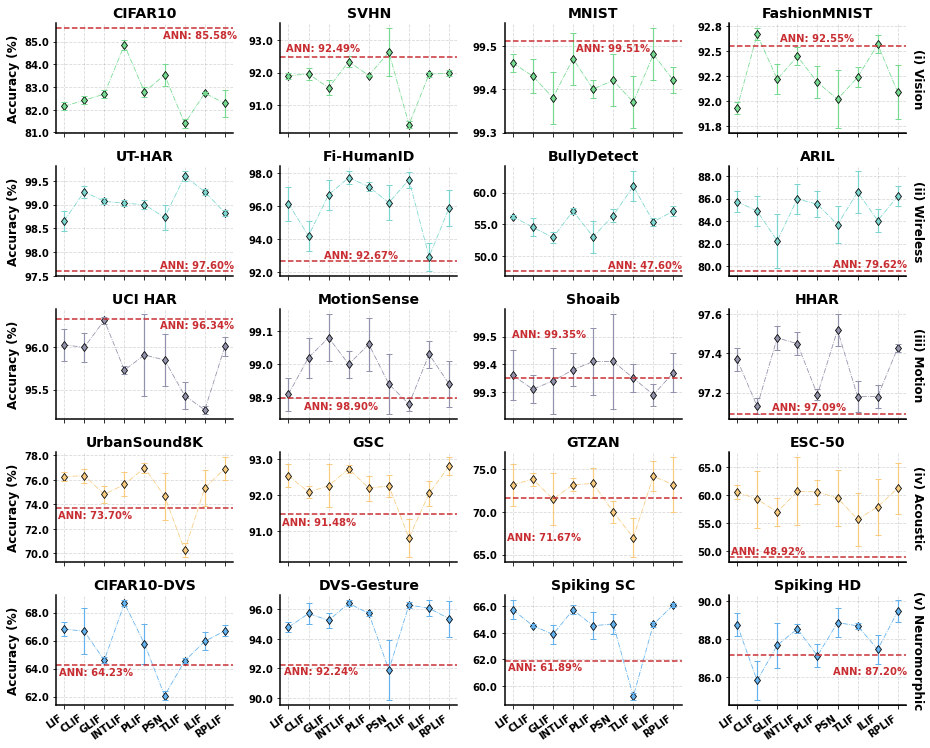

In [289]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
categories = ['ANN', 'LIF', 'CLIF', 'GLIF', 'INTLIF', 'PLIF', 'PSN', 'TLIF', 'ILIF', 'RPLIF']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_colors = ['#76da91', '#f8cb7f', '#9192ab', '#7cd6cf', '#63b2ee'] # ['#002c53', '#007f54', '#0c84c6', '#2455a4', '#625ba1']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x[1:])
        if i == 4:
            axs[i][j].set_xticklabels(categories[1:], rotation=35, ha='right')
            # for idx, tick in enumerate(axs[i][j].get_xticklabels()):
            #     if idx == 0:
            #         tick.set_color('#c82d31')
            #     else:
            #         tick.set_color('#194f97')
        else:
            axs[i][j].set_xticklabels([])

# (a) vision sensing
line_color = modality_colors[0]
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
mean_accs = [85.58, 82.15, 82.42, 82.69, 84.85, 82.79, 83.53, 81.40, 82.73, 82.28]
std_accs = [0.17, 0.17, 0.18, 0.18, 0.21, 0.21, 0.50, 0.21, 0.05, 0.58]
axs[0][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][0].text(len(categories) - 0.4, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='right', va='top')

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
mean_accs = [92.49, 91.90, 91.96, 91.53, 92.34, 91.91, 92.63, 90.40, 91.95, 91.98]
std_accs = [0.18, 0.09, 0.19, 0.23, 0.17, 0.03, 0.73, 0.11, 0.08, 0.09]
axs[0][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][1].text(len(categories[0]) - 0.3, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
mean_accs = [99.51, 99.46, 99.43, 99.38, 99.47, 99.40, 99.42, 99.37, 99.48, 99.42]
std_accs = [0.04, 0.02, 0.04, 0.06, 0.06, 0.02, 0.06, 0.06, 0.06, 0.03]
axs[0][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][2].text(6, mean_accs[0] - 0.005, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
mean_accs = [92.55, 91.93, 92.67, 92.22, 92.45, 92.19, 92.02, 92.24, 92.57, 92.09]
std_accs = [0.11, 0.06, 0.06, 0.15, 0.09, 0.16, 0.29, 0.10, 0.09, 0.27]
axs[0][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][3].text(5, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (d) Acoustic Sensing
line_color = modality_colors[1]
# urbansound
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
mean_accs = [73.70, 76.25, 76.34, 74.81, 75.62, 76.97, 74.67, 70.26, 75.34, 76.91]
std_accs = [1.18, 0.37, 0.58, 0.68, 0.98, 0.43, 1.91, 0.56, 1.47, 0.92]
axs[3][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][0].text(0.7, mean_accs[0] - 0.15, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GSC
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
mean_accs = [91.48, 92.55, 92.09, 92.26, 92.74, 92.20, 92.26, 90.81, 92.05, 92.82]
std_accs = [0.16, 0.31, 0.17, 0.6, 0.11, 0.35, 0.30, 0.54, 0.35, 0.24]
axs[3][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][1].text(0.7, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GTZAN
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
mean_accs = [71.67, 73.17, 73.83, 71.50, 73.17, 73.33, 70, 67, 74.17, 73.17]
std_accs = [1.61, 2.47, 0.76, 3.04, 0.76, 1.76, 1.32, 2.29, 1.76, 3.21]
axs[3][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][2].text(0.7, mean_accs[0] - 4, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# esc50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
mean_accs = [48.92, 60.58, 59.25, 57, 60.67, 60.58, 59.50, 55.67, 57.92, 61.25]
std_accs = [3.96, 1.18, 5.07, 2.46, 6.09, 2.13, 5.00, 4.77, 4.96, 4.55]
axs[3][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][3].text(0.7, mean_accs[0] + 0.2, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='bottom')

# (c) Motion Sensing
line_color = modality_colors[2]
# UCI HAR
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
mean_accs = [96.34, 96.03, 96, 96.32, 95.73, 95.91, 95.85, 95.43, 95.26, 96.01]
std_accs = [0.19, 0.19, 0.17, 0.04, 0.05, 0.48, 0.31, 0.16, 0.05, 0.11]
axs[2][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][0].text(7.6, mean_accs[0] - 0.02, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# MotionSense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
mean_accs = [98.90, 98.91, 99.02, 99.08, 99, 99.06, 98.94, 98.88, 99.03, 98.94]
std_accs = [0.05, 0.05, 0.06, 0.07, 0.04, 0.08, 0.09, 0.02, 0.04, 0.07]
axs[2][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][1].text(3.6, mean_accs[0] - 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# Shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
mean_accs = [99.35, 99.36, 99.31, 99.34, 99.38, 99.41, 99.41, 99.35, 99.29, 99.37]
std_accs = [0.02, 0.09, 0.05, 0.12, 0.06, 0.12, 0.17, 0.05, 0.04, 0.07]
axs[2][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][2].text(2.8, mean_accs[0] + 0.14, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# HHAR
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
mean_accs = [97.09, 97.37, 97.13, 97.48, 97.45, 97.19, 97.52, 97.18, 97.18, 97.43]
std_accs = [0.04, 0.06, 0.04, 0.06, 0.06, 0.03, 0.08, 0.08, 0.06, 0.02]
axs[2][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][3].text(4.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (b) Wireless Sensing
line_color = modality_colors[3]
# UT-HAR
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
mean_accs = [97.60, 98.66, 99.27, 99.07, 99.03, 99, 98.73, 99.60, 99.27, 98.83]
std_accs = [0.34, 0.21, 0.12, 0.06, 0.06, 0.10, 0.26, 0.10, 0.06, 0.06]
axs[1][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][0].text(7.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# NTU-Fi-HumanID
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
mean_accs = [92.67, 96.15, 94.20, 96.70, 97.74, 97.19, 96.21, 97.62, 92.92, 95.91]
std_accs = [2.16, 1.02, 0.92, 0.92, 0.38, 0.28, 1.06, 0.49, 0.87, 1.10]
axs[1][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][1].text(4.6, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# BullyDetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
mean_accs = [47.60, 56.22, 54.53, 52.92, 57.10, 53.03, 56.38, 61.01, 55.39, 57.10]
std_accs = [1.90, 0.30, 1.40, 0.87, 0.47, 2.55, 1.07, 2.35, 0.59, 0.74]
axs[1][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][2].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# ARIL
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
mean_accs = [79.62, 85.73, 84.89, 82.25, 85.97, 85.49, 83.69, 86.57, 84.05, 86.21]
std_accs = [2.39, 0.91, 1.30, 2.39, 1.30, 1.16, 1.62, 1.85, 1.04, 0.91]
axs[1][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][3].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')
axs[1][3].set_ylim(mean_accs[0] - 0.5)

# (e) Neuromorphic Sensing
line_color = modality_colors[4]
# cifar10dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
mean_accs = [64.23, 66.83, 66.67, 64.60, 68.67, 65.77, 62.07, 64.55, 65.95, 66.70]
std_accs = [0.68, 0.51, 1.64, 0.23, 0.21, 1.41, 0.32, 0.18, 0.65, 0.40]
axs[4][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][0].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
mean_accs = [92.24, 94.79, 95.72, 95.25, 96.41, 95.72, 91.90, 96.30, 96.07, 95.37]
std_accs = [1.06, 0.35, 0.72, 0.53, 0.20, 0.20, 2.04, 0.20, 0.53, 1.22]
axs[4][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][1].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
mean_accs = [61.89, 65.75, 64.55, 63.89, 65.74, 64.54, 64.68, 59.21, 64.66, 66.11]
std_accs = [1.26, 0.71, 0.12, 0.70, 0.33, 1.02, 0.75, 0.28, 0.19, 0.14]
axs[4][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][2].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# shd
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
mean_accs = [87.20, 88.78, 85.84, 87.69, 88.55, 87.14, 88.88, 88.71, 87.47, 89.48]
std_accs = [0.42, 0.62, 1.03, 1.19, 0.24, 0.60, 0.75, 0.14, 0.78, 0.57]
axs[4][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][3].text(7.6, mean_accs[0] - 0.6, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

fig.tight_layout()
plt.savefig('./cmp-lif-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

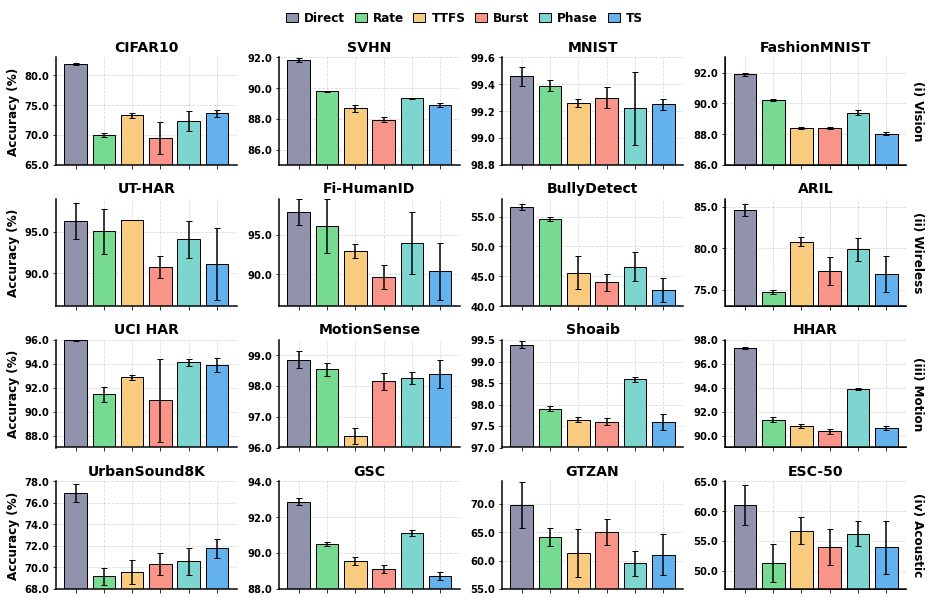

In [288]:
fig, axs = plt.subplots(4, 4, figsize=(13, 8))
categories = ['Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TS']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic']
for i in range(4):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x)
        axs[i][j].set_xticklabels([])

axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)

axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)

axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)

axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

# cifar10:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [81.83, 69.95, 73.33, 69.53, 72.35, 73.67]
errors = [0.17, 0.32, 0.40, 2.63, 1.66, 0.59]
axs[0][0].set_ylim(65, 83)
for i in x:
    axs[0][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i], label=categories[i],
        edgecolor='black', zorder=2)
    
# svhn:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.83, 89.78, 88.70, 87.95, 89.34, 88.89]
errors = [0.13, 0.04, 0.23, 0.17, 0.02, 0.11]
axs[0][1].set_ylim(85, 92)
for i in x:
    axs[0][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# mnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.46, 99.39, 99.26, 99.30, 99.22, 99.25]
errors = [0.07, 0.04, 0.03, 0.08, 0.27, 0.04]
axs[0][2].set_ylim(98.8, 99.6)
for i in x:
    axs[0][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# fashionmnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.90, 90.21, 88.42, 88.42, 89.40, 88.04]
errors = [0.11, 0.08, 0.08, 0.08, 0.18, 0.07]
axs[0][3].set_ylim(86, 93)
for i in x:
    axs[0][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# ut har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [96.30, 95.06, 96.39, 90.73, 94.07, 91.12]
errors = [2.17, 2.72, 0., 1.38, 2.27, 4.36]
axs[1][0].set_ylim(86, 99)
for i in x:
    axs[1][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# fi-humanid:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.82, 96.07, 92.92, 89.67, 93.92, 90.40]
errors = [1.61, 3.42, 0.92, 1.53, 3.93, 3.57]
axs[1][1].set_ylim(86, 99.5)
for i in x:
    axs[1][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# bullydetect:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [56.65, 54.64, 45.64, 44.03, 46.59, 42.63]
errors = [0.47, 0.32, 2.79, 1.43, 2.41, 2.01]
axs[1][2].set_ylim(40, 58)
for i in x:
    axs[1][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# aril:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [84.65, 74.70, 80.82, 77.22, 79.86, 76.86]
errors = [0.75, 0.21, 0.55, 1.70, 1.44, 2.20]
axs[1][3].set_ylim(73, 86)
for i in x:
    axs[1][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# uci har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'   
values = [96.02, 91.47, 92.87, 90.95, 94.15, 93.92]
errors = [0.09, 0.63, 0.18, 3.45, 0.3, 0.58]
axs[2][0].set_ylim(87, 96)
for i in x:
    axs[2][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# motionsense:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [98.86, 98.54, 96.38, 98.16, 98.26, 98.39]
errors = [0.28, 0.22, 0.27, 0.28, 0.19, 0.45]
axs[2][1].set_ylim(96., 99.5)
for i in x:
    axs[2][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# shoaib:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.39, 97.90, 97.65, 97.60, 98.59, 97.59]
errors = [0.08, 0.06, 0.05, 0.08, 0.06, 0.18]
axs[2][2].set_ylim(97, 99.5)
for i in x:
    axs[2][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# hhar:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.32, 91.33, 90.82, 90.34, 93.87, 90.61]
errors = [0.07, 0.20, 0.16, 0.18, 0.09, 0.17]
axs[2][3].set_ylim(89, 98)
for i in x:
    axs[2][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)


# urbansound8k:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [76.95, 69.15, 69.59, 70.28, 70.54, 71.77]
errors = [0.84, 0.8, 1.13, 1.04, 1.27, 0.87]
axs[3][0].set_ylim(68, 78)
for i in x:
    axs[3][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GSC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [92.85, 90.51, 89.57, 89.10, 91.10, 88.72]
errors = [0.20, 0.11, 0.22, 0.22, 0.17, 0.21]
axs[3][1].set_ylim(88, 94)
for i in x:
    axs[3][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GTZAN:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [69.83, 64.17, 61.33, 65, 59.50, 61]
errors = [4.01, 1.61, 4.31, 2.29, 2.18, 3.61]
axs[3][2].set_ylim(55, 74)
for i in x:
    axs[3][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# ESC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [61, 51.33, 56.75, 54, 56.25, 53.92]
errors = [3.36, 3.22, 2.29, 3.04, 2.14, 4.50]
axs[3][3].set_ylim(47, 65)
for i in x:
    axs[3][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

fig.legend(
    categories, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(categories), 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)
fig.tight_layout()
plt.savefig('./cmp-encoding-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

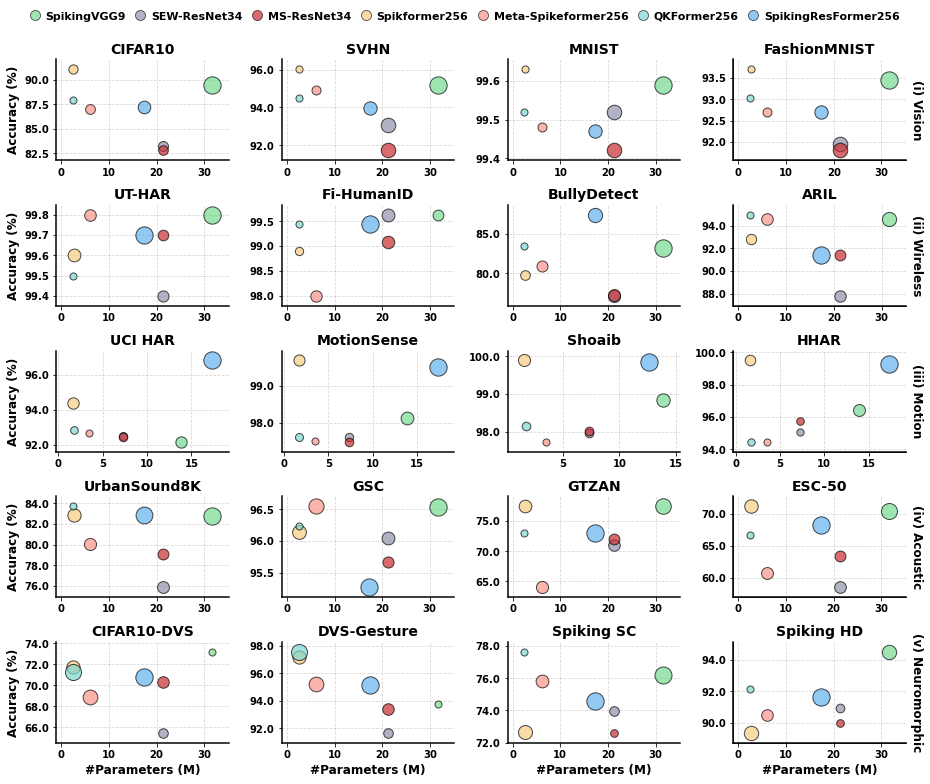

In [3]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
colors = ['#76da91', '#9192ab', '#c82d31', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        if i == 4:
            axs[i][j].set_xlabel('#Parameters (M)', fontweight='bold', fontsize=12)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
    
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


def adjust_ylim(ax, y, x=None, pad_ratio=0.12):
    y = np.array(y)
    y_min, y_max = y.min(), y.max()
    y_range = y_max - y_min
    ax.set_ylim(
        y_min - pad_ratio * y_range,
        y_max + pad_ratio * y_range
    )

    if x is not None:
        x = np.array(x)
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        ax.set_xlim(
            x_min - pad_ratio * x_range,
            x_max + pad_ratio * x_range
        )

s_min, s_max = 50, 300

categories = ['SpikingVGG9', 'SEW-ResNet34','MS-ResNet34', 'Spikformer256', 
              'Meta-Spikeformer256', 'QKFormer256', 'SpikingResFormer256'] # vgg9, resnet34, former2
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
accs = [89.53, 83.29, 82.79, 91.11, 87.07, 87.93, 87.22]
params = [31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([820.67, 198.23, 176, 153.31, 185.61, 42.31, 384.46])
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][0], accs, params)

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
accs = [95.2, 93.08, 91.73, 96.02, 94.93, 94.51, 93.97]
params = np.array([31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32])
costs = np.array([1661.38, 202.65, 177.08, 169.56, 182.88, 45.19, 383.36]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][1], accs, params)

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
accs = [99.59, 99.52, 99.42, 99.63, 99.48, 99.52, 99.47]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1273.11, 77.77, 69.04, 92.03, 89.69, 23.08, 264.03]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][2], accs, params)

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
accs = [93.46, 91.95, 91.8, 93.71, 92.71, 93.04, 92.71]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1192.67, 34.02, 30.25, 114.22, 94.22, 25.81, 199.25]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][3], accs, params)

# ut-har
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
accs = [99.8, 99.4, 99.7, 99.6, 99.8, 99.5, 99.7]
params = [31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([4790.23, 1717.97, 1513.71, 2396.2, 1899.94, 426.07, 4748.38]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][0], accs, params)

# fi-humanid
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
accs = [99.63, 99.63, 99.08, 98.9, 97.99, 99.45, 99.45]
params = [31.62, 21.29, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([7392.13, 11482.72, 10700.59, 3282.74, 8416.59, 1675.69, 22965.19]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][1], accs, params)

# bullydetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
accs = [83.26, 77.1, 77.19, 79.82, 80.89, 83.44, 87.46]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.41, 17.32]
costs = np.array([6881.04, 3045.48, 2873.80, 1645.20, 2366.06, 533.35, 4427.03]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][2], accs, params)

# aril
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
accs = [94.60, 87.77, 91.37, 92.81, 94.60, 94.96, 91.37]
params = [31.60, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([1474.34, 868.95, 749.84, 672.84, 901.83, 180.52, 2307.88]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][3], accs, params)

# uci-har
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
accs = [92.16, 92.47, 92.43, 94.37, 92.64, 92.81, 96.81]
params = [13.87, 7.28, 7.28, 1.63, 3.51, 1.74, 17.31]
costs = np.array([29.79, 10.59, 12.67, 30.31, 5.51, 8.18, 83.15]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][0], accs, params)

# motionsense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
accs = [98.12, 97.6, 97.48, 99.7, 97.51, 97.6, 99.52]
params = [13.87, 7.28, 7.28, 1.64, 3.51, 1.74, 17.31]
costs = np.array([50.23, 15.11, 16.4, 35.43, 7.72, 13.08, 101.6]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][1], accs, params)

# shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
accs = [98.84, 97.95, 98.02, 99.89, 97.73, 98.16, 99.86]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 12.56]
costs = np.array([51.65, 15.77, 16.55, 40.49, 7.39, 15.73, 93.65]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][2], accs, params)

# hhar
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
accs = [96.4, 95.05, 95.75, 99.49, 94.47, 94.48, 99.26]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 17.31]
costs = np.array([39.55, 3.41, 5.8, 27.32, 2.36, 3.96, 102.73]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][3], accs, params)

# urbansound8k
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
accs = [82.76, 75.86, 79.07, 82.88, 80.04, 83.73, 82.88]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([3425.88, 1458.24, 1185.28, 1885.05, 1544.79, 328.97, 3219.93]) / 1000 # mj
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][0], accs, params)

# gsc
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
accs = [96.53, 96.04, 95.67, 96.14, 96.55, 96.23, 95.27]
params = np.array([31.66, 21.3, 21.3, 2.57, 6.09, 2.41, 17.32])
costs = np.array([2824.65, 1573.78, 1189.65, 1808.95, 2195.36, 511, 2789.32]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][1], accs, params)

# gtzan
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
accs = [77.5, 71, 72, 77.5, 64, 73, 73]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([2908.94, 1431.12, 1214.06, 1784.31, 1632.79, 311.82, 3672.51]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][2], accs, params)

# esc-50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
accs = [70.5, 58.5, 63.5, 71.25, 60.75, 66.75, 68.25]
params = [31.69, 21.3, 21.31, 2.58, 6.09, 2.43, 17.33]
costs = np.array([2931.87, 1433.94, 1196.17, 1981.97, 1485.05, 324.71, 3471.66]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][3], accs, params)


# cifar10-dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
accs = [73.2, 65.45, 70.35, 71.7, 68.85, 71.3, 70.8]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][0], accs, params)

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
accs = [93.75, 91.67, 93.4, 97.22, 95.24, 97.57, 95.14]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][1], accs, params)

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
accs = [76.22, 73.96, 72.6, 72.69, 75.83, 77.64, 74.61]
params = [31.66, 21.3, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([5160.73, 1419.89, 775.27, 3382.03, 2731.23, 589.53, 5357.59]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][2], accs, params)

# shd   
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
accs = [94.52, 90.95, 89.97, 89.36, 90.5, 92.14, 91.65]
params = [31.63, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([4796.67, 1314.91, 847.97, 4804.35, 2903.08, 603.97, 7333.23]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][3], accs, params)


legend_size = 70
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=colors[i],
        markeredgecolor='black',
        markeredgewidth=0.8,
        alpha=0.7,
        markersize=np.sqrt(legend_size),  # 注意：markersize 是“半径”
        label=categories[i]
    )
    for i in range(len(categories))
]
fig.legend(
    handles=legend_handles,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.04), 
    ncol=7, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    markerscale=1.2,
    prop={'weight': 'bold', 'size': 11},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-topology-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()